<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/1A_DBA_Archived_HPI_Grth_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [6]:
df = pd.read_csv('/content/merged_hpi_rent_repo.csv')
print("Top 5 records:")
print(df.head())
print("\nShape of the DataFrame:")
print(df.shape)

Top 5 records:
        city  quarter      rent         hpi  hpi_growth  hpi_norm  repo_rate  \
0  bangalore  Q1 2014  100.0000  142.266366    0.064893  1.373227   8.804847   
1  bangalore  Q2 2014  108.2750  150.373377    0.096215  1.451480   8.791340   
2  bangalore  Q3 2014   99.5375  169.256843    0.181414  1.633753   8.569230   
3  bangalore  Q4 2014  109.8875  184.285621    0.217250  1.778819   8.181552   
4  bangalore  Q1 2015  104.4500  180.400000    0.237475  1.741313   7.782887   

         date  
0  2014-01-01  
1  2014-04-01  
2  2014-07-01  
3  2014-10-01  
4  2015-01-01  

Shape of the DataFrame:
(232, 8)


In [7]:
df = pd.read_csv("merged_hpi_rent_repo.csv")

df = df.sort_values(["city","quarter"])
df["rent_growth"] = df.groupby("city")["rent"].pct_change(fill_method=None)
# Assuming 'repo_rate' column exists in the CSV for repo rate calculation
df["repo_growth"] = df.groupby("city")["repo_rate"].pct_change(fill_method=None)
df = df.dropna(subset=["rent_growth","hpi_growth","repo_growth"])
#Ensure Categorical FE
df["city"]=df["city"].astype("category")

In [8]:
#ADF

In [9]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: p-value = {result[1]:.4f}")

for city in df["city"].unique():
    print(f"\nADF - {city}")
    adf_test(df[df["city"]==city]["rent_growth"], "rent_growth")
    adf_test(df[df["city"]==city]["hpi_growth"], "hpi_growth")


ADF - bangalore
rent_growth: p-value = 0.0000
hpi_growth: p-value = 0.0000

ADF - chennai
rent_growth: p-value = 0.0063
hpi_growth: p-value = 0.0000

ADF - delhi
rent_growth: p-value = 0.0000
hpi_growth: p-value = 0.0000

ADF - mumbai
rent_growth: p-value = 0.0000
hpi_growth: p-value = 0.0000


In [10]:
X = df[["rent_growth"]].copy()
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

       feature       VIF
0        const  1.099003
1  rent_growth  1.000000


In [11]:
X = df[["rent_growth","hpi_growth"]].dropna()
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

       feature       VIF
0        const  1.112499
1  rent_growth  1.033832
2   hpi_growth  1.033832


In [12]:
model = smf.ols(
    "hpi_growth ~ rent_growth + C(city)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.703
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.151
Time:                        10:44:59   Log-Likelihood:                -196.13
No. Observations:                 204   AIC:                             402.3
Df Residuals:                     199   BIC:                             418.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0883      0

In [13]:
bp_test = het_breuschpagan(model.resid, model.model.exog)

print("BP p-value:", bp_test[1])

BP p-value: 0.24644031908557856


In [14]:
model_hac = smf.ols(
      "hpi_growth ~ rent_growth + C(city)",
          data=df
          ).fit(cov_type="HAC", cov_kwds={"maxlags":1})

print(model_hac.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.851
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.121
Time:                        10:44:59   Log-Likelihood:                -196.13
No. Observations:                 204   AIC:                             402.3
Df Residuals:                     199   BIC:                             418.8
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0883      0

In [15]:
df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)

df_dyn = df.dropna()

model_dyn = smf.ols(
    "hpi_growth ~ rent_growth + hpi_lag + C(city)",
        data=df_dyn
        ).fit(cov_type="HAC", cov_kwds={"maxlags":1})

print(model_dyn.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     72.65
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.37e-42
Time:                        10:44:59   Log-Likelihood:                -100.33
No. Observations:                 200   AIC:                             212.7
Df Residuals:                     194   BIC:                             232.5
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.1032      0

/tmp/ipykernel_4531/1311684452.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)


In [16]:
df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
df["repo_growth_lag"] = df.groupby("city")["repo_growth"].shift(1)

df_dyn = df.dropna()


/tmp/ipykernel_4531/3382915828.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
/tmp/ipykernel_4531/3382915828.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["repo_growth_lag"] = df.groupby("city")["repo_growth"].shift(1)


In [17]:
# Add repo_growth to the dynamic model
model_dyn_with_repo = smf.ols(
    "hpi_growth ~ rent_growth + hpi_lag + repo_growth + C(city)",
    data=df_dyn
).fit(cov_type="HAC", cov_kwds={"maxlags":1})

print(model_dyn_with_repo.summary())

                            OLS Regression Results                            
Dep. Variable:             hpi_growth   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     61.74
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.64e-42
Time:                        10:44:59   Log-Likelihood:                -99.301
No. Observations:                 200   AIC:                             212.6
Df Residuals:                     193   BIC:                             235.7
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0999      0

In [18]:
print(df.columns)

Index(['city', 'quarter', 'rent', 'hpi', 'hpi_growth', 'hpi_norm', 'repo_rate',
       'date', 'rent_growth', 'repo_growth', 'hpi_lag', 'rent_growth_lag',
       'repo_growth_lag'],
      dtype='object')


In [19]:
df  # your dataset

,city,quarter,rent,hpi,hpi_growth,hpi_norm,repo_rate,date,rent_growth,repo_growth,hpi_lag,rent_growth_lag,repo_growth_lag
4,bangalore,Q1 2015,104.450000,180.400000,0.237475,1.741313,7.782887,2015-01-01,0.044500,-0.116068,NaN,NaN,NaN
8,bangalore,Q1 2016,114.600000,208.418714,0.144372,2.011764,7.657853,2016-01-01,0.097176,-0.016065,0.237475,0.044500,-0.116068
12,bangalore,Q1 2017,121.987500,220.607905,0.056838,2.129420,6.962920,2017-01-01,0.064463,-0.090748,0.144372,0.097176,-0.016065
16,bangalore,Q1 2018,145.225000,227.657667,0.031456,2.197468,7.466353,2018-01-01,0.190491,0.072302,0.056838,0.064463,-0.090748
20,bangalore,Q1 2019,144.737500,244.842538,0.072772,2.363345,7.397403,2019-01-01,-0.003357,-0.009235,0.031456,0.190491,0.072302
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,mumbai,Q4 2022,114.485714,396.825664,-0.003959,3.420911,7.372220,2022-10-01,0.055585,0.154647,0.007306,-0.019881,0.080164
216,mumbai,Q4 2023,124.600000,414.846889,0.044412,3.576266,7.281333,2023-10-01,0.088345,-0.012328,-0.003959,0.055585,0.154647
217,mumbai,Q4 2023,124.600000,99.862488,-1.424115,0.860884,7.281333,2023-10-01,0.000000,0.000000,0.044412,0.088345,-0.012328
224,mumbai,Q4 2024,135.300000,416.888558,1.429025,3.593867,6.791500,2024-10-01,0.085875,-0.067272,-1.424115,0.000000,0.000000


In [20]:
import statsmodels.formula.api as smf

In [21]:
formula = "hpi_growth ~ rent_growth + hpi_lag + repo_growth + C(city)"

In [22]:
formula = "hpi_growth ~ hpi_lag + rent_growth_lag + repo_growth_lag + rent_growth + repo_growth + C(city)"


In [23]:
model_50 = smf.quantreg(formula, df)
res_50 = model_50.fit(q=0.5)

print(res_50.summary())

                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.4291
Model:                       QuantReg   Bandwidth:                     0.09767
Method:                 Least Squares   Sparsity:                       0.2846
Date:                Thu, 30 Apr 2026   No. Observations:                  200
Time:                        10:44:59   Df Residuals:                      191
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0545      0.022      2.504      0.013       0.012       0.098
C(city)[T.chennai]    -0.0070      0.029     -0.244      0.807      -0.063       0.049
C(city)[T.delhi]      -0.0088      0.029     -0.302      0.763      -0.067       0.049
C(city)[T.mu

In [24]:
model_50 = smf.quantreg(formula, df_dyn)
res_50 = model_50.fit(q=0.5)

print(res_50.summary())


                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.4291
Model:                       QuantReg   Bandwidth:                     0.09767
Method:                 Least Squares   Sparsity:                       0.2846
Date:                Thu, 30 Apr 2026   No. Observations:                  200
Time:                        10:44:59   Df Residuals:                      191
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0545      0.022      2.504      0.013       0.012       0.098
C(city)[T.chennai]    -0.0070      0.029     -0.244      0.807      -0.063       0.049
C(city)[T.delhi]      -0.0088      0.029     -0.302      0.763      -0.067       0.049
C(city)[T.mu

In [25]:
model_10 = smf.quantreg(formula, df)
res_10 = model_10.fit(q=0.1)

print(res_10.summary())

                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.2864
Model:                       QuantReg   Bandwidth:                      0.3894
Method:                 Least Squares   Sparsity:                        2.422
Date:                Thu, 30 Apr 2026   No. Observations:                  200
Time:                        10:44:59   Df Residuals:                      191
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.7839      0.107     -7.313      0.000      -0.995      -0.572
C(city)[T.chennai]     0.2395      0.155      1.543      0.124      -0.067       0.546
C(city)[T.delhi]      -0.1152      0.152     -0.756      0.451      -0.416       0.185
C(city)[T.mu

In [26]:
model_10 = smf.quantreg(formula, df_dyn)
res_10 = model_10.fit(q=0.1)

print(res_10.summary())


                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.2864
Model:                       QuantReg   Bandwidth:                      0.3894
Method:                 Least Squares   Sparsity:                        2.422
Date:                Thu, 30 Apr 2026   No. Observations:                  200
Time:                        10:44:59   Df Residuals:                      191
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.7839      0.107     -7.313      0.000      -0.995      -0.572
C(city)[T.chennai]     0.2395      0.155      1.543      0.124      -0.067       0.546
C(city)[T.delhi]      -0.1152      0.152     -0.756      0.451      -0.416       0.185
C(city)[T.mu

In [27]:
model_90 = smf.quantreg(formula, df)
res_90 = model_90.fit(q=0.9)

print(res_90.summary())

                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.7517
Model:                       QuantReg   Bandwidth:                      0.1551
Method:                 Least Squares   Sparsity:                       0.4769
Date:                Thu, 30 Apr 2026   No. Observations:                  200
Time:                        10:44:59   Df Residuals:                      191
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2426      0.022     11.001      0.000       0.199       0.286
C(city)[T.chennai]    -0.0019      0.031     -0.060      0.952      -0.063       0.059
C(city)[T.delhi]       0.0137      0.031      0.448      0.654      -0.047       0.074
C(city)[T.mu

In [28]:
model_90 = smf.quantreg(formula, df_dyn)
res_90 = model_90.fit(q=0.9)

print(res_90.summary())


                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.7517
Model:                       QuantReg   Bandwidth:                      0.1551
Method:                 Least Squares   Sparsity:                       0.4769
Date:                Thu, 30 Apr 2026   No. Observations:                  200
Time:                        10:44:59   Df Residuals:                      191
                                        Df Model:                            8
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2426      0.022     11.001      0.000       0.199       0.286
C(city)[T.chennai]    -0.0019      0.031     -0.060      0.952      -0.063       0.059
C(city)[T.delhi]       0.0137      0.031      0.448      0.654      -0.047       0.074
C(city)[T.mu

In [29]:
import pandas as pd

coeffs = pd.DataFrame({
    "q10": res_10.params,
    "q50": res_50.params,
    "q90": res_90.params
})

print(coeffs)

                         q10       q50       q90
Intercept          -0.783861  0.054538  0.242633
C(city)[T.chennai]  0.239530 -0.006973 -0.001860
C(city)[T.delhi]   -0.115249 -0.008840  0.013738
C(city)[T.mumbai]   0.288056 -0.026875  0.028495
hpi_lag            -0.528552 -0.926852 -0.850716
rent_growth_lag    -3.223823 -0.224561 -0.563522
repo_growth_lag    -1.672136 -0.405347 -0.468256
rent_growth         3.546091  0.914347 -0.347259
repo_growth         0.907832 -0.605939 -0.517926


In [30]:
coeffs = pd.DataFrame({
    "q10": res_10.params,
    "q50": res_50.params,
    "q90": res_90.params
})

print(coeffs)


                         q10       q50       q90
Intercept          -0.783861  0.054538  0.242633
C(city)[T.chennai]  0.239530 -0.006973 -0.001860
C(city)[T.delhi]   -0.115249 -0.008840  0.013738
C(city)[T.mumbai]   0.288056 -0.026875  0.028495
hpi_lag            -0.528552 -0.926852 -0.850716
rent_growth_lag    -3.223823 -0.224561 -0.563522
repo_growth_lag    -1.672136 -0.405347 -0.468256
rent_growth         3.546091  0.914347 -0.347259
repo_growth         0.907832 -0.605939 -0.517926


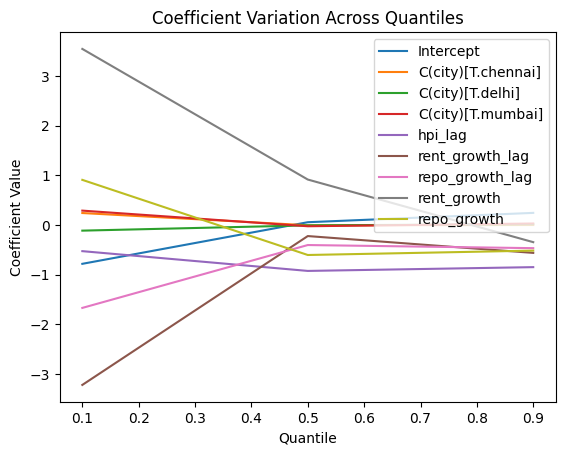

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

quantiles = [0.1, 0.5, 0.9]
results = []

for q in quantiles:
    res = smf.quantreg(formula, df).fit(q=q)
    results.append(res.params)

coef_df = pd.DataFrame(results, index=quantiles)

coef_df.plot()
plt.title("Coefficient Variation Across Quantiles")
plt.xlabel("Quantile")
plt.ylabel("Coefficient Value")
plt.show()

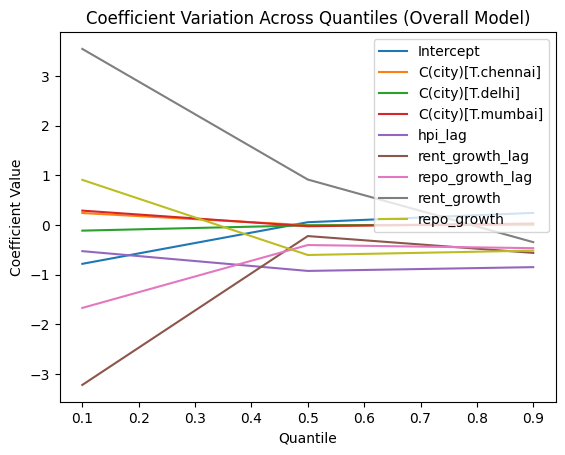

In [32]:
quantiles = [0.1, 0.5, 0.9]
results = []

for q in quantiles:
    res = smf.quantreg(formula, df_dyn).fit(q=q)
    results.append(res.params)

coef_df = pd.DataFrame(results, index=quantiles)

coef_df.plot()
plt.title("Coefficient Variation Across Quantiles (Overall Model)")
plt.xlabel("Quantile")
plt.ylabel("Coefficient Value")
plt.show()


In [33]:
df['date'] = pd.to_datetime(df['date'])
min_date = df['date'].min()
max_date = df['date'].max()
print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2014-04-01 00:00:00
Maximum Date: 2025-01-01 00:00:00


In [34]:
df_dyn['date'] = pd.to_datetime(df_dyn['date'])
print(df_dyn['date'].dt.year.unique())

[2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2014 2015]


/tmp/ipykernel_4531/3541794707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dyn['date'] = pd.to_datetime(df_dyn['date'])


In [35]:
display(df_dyn.describe())

,rent,hpi,hpi_growth,hpi_norm,repo_rate,date,rent_growth,repo_growth,hpi_lag,rent_growth_lag,repo_growth_lag
count,200.000000,200.000000,200.000000,200.000000,200.000000,200,200.000000,200.000000,200.000000,200.000000,200.000000
mean,132.802768,262.394645,-0.041963,2.511348,7.061855,2020-09-14 02:24:00,0.023215,-0.005496,-0.014504,0.025582,-0.007818
min,94.500000,92.596610,-1.440046,0.860884,5.910980,2014-04-01 00:00:00,-0.433189,-0.152852,-1.440046,-0.433189,-0.152852
25%,111.739286,205.650681,-0.011367,2.018862,6.737775,2018-01-01 00:00:00,0.000000,-0.069380,-0.008258,0.000000,-0.084087
50%,124.750000,279.740470,0.050619,2.820771,7.100608,2021-02-15 00:00:00,0.021833,-0.010782,0.059934,0.024807,-0.014197
75%,150.925000,333.256289,0.128961,3.196891,7.361508,2023-07-01 00:00:00,0.065410,0.046351,0.139632,0.065831,0.046351
max,191.212500,425.775056,1.445051,3.670475,8.791340,2025-01-01 00:00:00,0.205856,0.300879,1.445051,0.319500,0.300879
std,25.667643,94.717018,0.650559,0.855488,0.542964,NaN,0.077663,0.095671,0.631181,0.080624,0.096916


### Quantile Regression Segmented by City

Now, let's run the quantile regression for each city individually to observe how the relationships between HPI growth, rent growth, lagged HPI growth, and repo rate growth differ across cities at various quantiles.

In [36]:
formula_city = "hpi_growth ~ rent_growth + hpi_lag + repo_growth"

unique_cities = df_dyn['city'].unique()

for city_name in unique_cities:
    print(f"\n--- City: {city_name.upper()} ---")
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7: # Need at least k+1 observations for k regressors (3 regressors + intercept = 4, so 7 to be safe for quantreg)
        print(f"Not enough observations for {city_name}. Skipping.")
        continue

    # Run Quantile Regression for q=0.1
    print("\n--- Quantile: 0.1 ---")
    model_10_city = smf.quantreg(formula_city, df_city)
    res_10_city = model_10_city.fit(q=0.1)
    print(res_10_city.summary())

    # Run Quantile Regression for q=0.5
    print("\n--- Quantile: 0.5 ---")
    model_50_city = smf.quantreg(formula_city, df_city)
    res_50_city = model_50_city.fit(q=0.5)
    print(res_50_city.summary())

    # Run Quantile Regression for q=0.9
    print("\n--- Quantile: 0.9 ---")
    model_90_city = smf.quantreg(formula_city, df_city)
    res_90_city = model_90_city.fit(q=0.9)
    print(res_90_city.summary())



--- City: BANGALORE ---

--- Quantile: 0.1 ---
                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.2768
Model:                       QuantReg   Bandwidth:                      0.9456
Method:                 Least Squares   Sparsity:                        2.593
Date:                Thu, 30 Apr 2026   No. Observations:                   50
Time:                        10:45:01   Df Residuals:                       46
                                        Df Model:                            3
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.1569      0.143     -8.090      0.000      -1.445      -0.869
rent_growth     7.1896      1.854      3.879      0.000       3.458      10.921
hpi_lag        -0.0278      0.224     -0.124      0.902      -0.478       0.422

In [37]:
formula_city = "hpi_growth ~ hpi_lag + rent_growth_lag + repo_growth_lag + rent_growth + repo_growth"

unique_cities = df_dyn['city'].unique()

for city_name in unique_cities:
    print(f"\n--- City: {city_name.upper()} ---")
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7: # Need at least k+1 observations for k regressors (5 regressors + intercept = 6)
        print(f"Not enough observations for {city_name}. Skipping.")
        continue

    # Run Quantile Regression for q=0.1
    print("\n--- Quantile: 0.1 ---")
    model_10_city = smf.quantreg(formula_city, df_city)
    res_10_city = model_10_city.fit(q=0.1)
    print(res_10_city.summary())

    # Run Quantile Regression for q=0.5
    print("\n--- Quantile: 0.5 ---")
    model_50_city = smf.quantreg(formula_city, df_city)
    res_50_city = model_50_city.fit(q=0.5)
    print(res_50_city.summary())

    # Run Quantile Regression for q=0.9
    print("\n--- Quantile: 0.9 ---")
    model_90_city = smf.quantreg(formula_city, df_city)
    res_90_city = model_90_city.fit(q=0.9)
    print(res_90_city.summary())



--- City: BANGALORE ---

--- Quantile: 0.1 ---
                         QuantReg Regression Results                          
Dep. Variable:             hpi_growth   Pseudo R-squared:               0.3518
Model:                       QuantReg   Bandwidth:                       1.048
Method:                 Least Squares   Sparsity:                        2.636
Date:                Thu, 30 Apr 2026   No. Observations:                   50
Time:                        10:45:01   Df Residuals:                       44
                                        Df Model:                            5
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6600      0.238     -2.775      0.008      -1.139      -0.181
hpi_lag            -0.4645      0.283     -1.642      0.108      -1.035       0.106
rent_growth_lag    -4.1128      3.512     -1.171      0.248    

### Quantile Regression Coefficients and Significance by City and Quantile



,City,Quantile,Variable,Coefficient,P-value,Significant (p<0.05)
0,bangalore,0.1,Intercept,-1.156874,2.181912e-10,True
1,bangalore,0.1,rent_growth,7.189582,3.323765e-04,True
2,bangalore,0.1,hpi_lag,-0.027817,9.015733e-01,False
3,bangalore,0.1,repo_growth,-2.484544,1.652783e-02,True
4,bangalore,0.5,Intercept,0.010616,7.458288e-01,False
5,bangalore,0.5,rent_growth,1.591117,1.589968e-04,True
6,bangalore,0.5,hpi_lag,-0.923472,3.881438e-24,True
7,bangalore,0.5,repo_growth,-0.657171,4.930804e-02,True
8,bangalore,0.9,Intercept,0.186909,7.933419e-09,True
9,bangalore,0.9,rent_growth,0.947843,4.472377e-04,True



### Visualization of Coefficients Across Quantiles by City



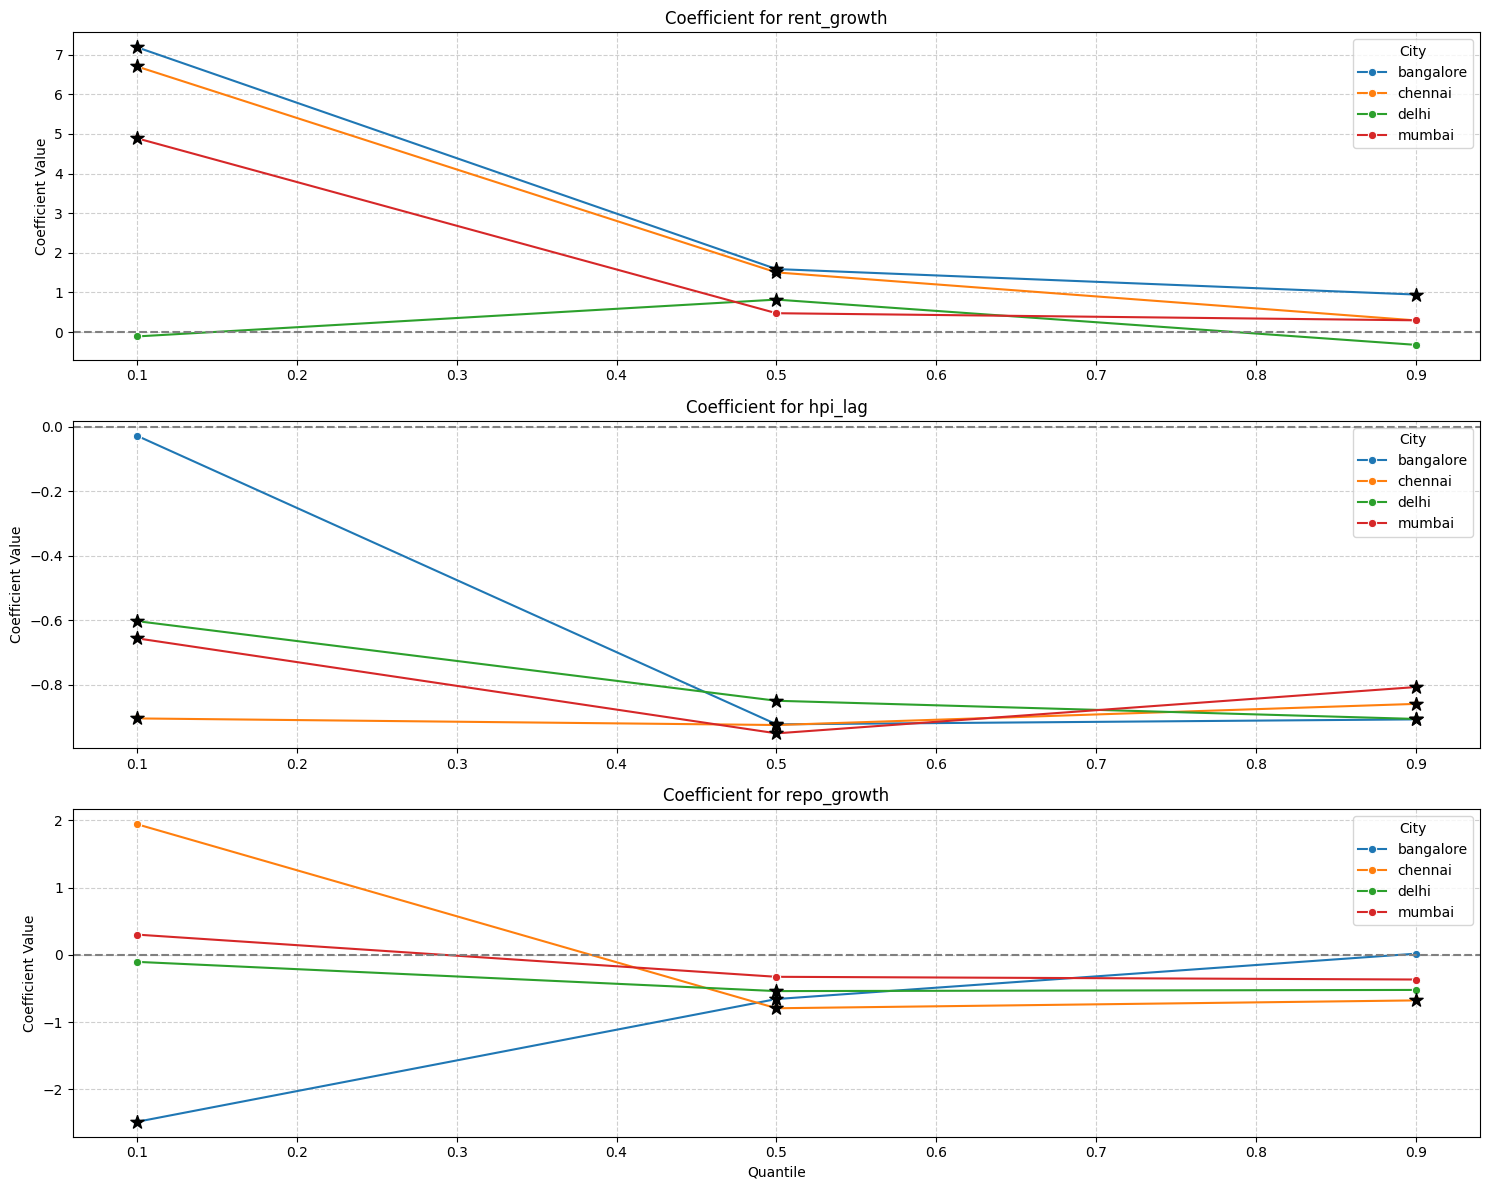

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Define the formula and quantiles (using the formula_city defined previously)
formula_city = "hpi_growth ~ rent_growth + hpi_lag + repo_growth"
quantiles = [0.1, 0.5, 0.9]
unique_cities = df_dyn['city'].unique()

# Store results
all_results = []

for city_name in unique_cities:
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7:
        print(f"Skipping {city_name} due to insufficient observations.")
        continue

    for q in quantiles:
        model = smf.quantreg(formula_city, df_city)
        res = model.fit(q=q)

        # Extract coefficients and p-values
        params = res.params
        pvalues = res.pvalues

        for param_name in params.index:
            all_results.append({
                'City': city_name,
                'Quantile': q,
                'Variable': param_name,
                'Coefficient': params[param_name],
                'P-value': pvalues[param_name],
                'Significant (p<0.05)': pvalues[param_name] < 0.05
            })

# Create a DataFrame from the collected results
results_df = pd.DataFrame(all_results)

# --- Display as a Table ---
print("### Quantile Regression Coefficients and Significance by City and Quantile\n")
display(results_df)

# --- Plot the Coefficients ---
print("\n### Visualization of Coefficients Across Quantiles by City\n")

# Filter out the 'Intercept' for plotting clarity, as its scale can be very different
plot_df = results_df[results_df['Variable'].isin(['rent_growth', 'hpi_lag', 'repo_growth'])]

# Get unique variables to plot separately
unique_variables = plot_df['Variable'].unique()

plt.figure(figsize=(15, 12))
for i, var in enumerate(unique_variables):
    plt.subplot(len(unique_variables), 1, i + 1)
    sns.lineplot(data=plot_df[plot_df['Variable'] == var], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

    # Add significance markers
    for _, row in plot_df[(plot_df['Variable'] == var) & (plot_df['Significant (p<0.05)'] == True)].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficient for {var}')
    plt.axhline(0, color='grey', linestyle='--')
    plt.grid(True, linestyle='--', alpha=0.6)
    if i < len(unique_variables) - 1:
        plt.xlabel('') # Remove x-label for intermediate plots
    else:
        plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')

plt.tight_layout()
plt.show()

### Quantile Regression Coefficients and Significance by City and Quantile (Updated Formula)



,City,Quantile,Variable,Coefficient,P-value,Significant (p<0.05)
0,bangalore,0.1,Intercept,-0.660000,8.080105e-03,True
1,bangalore,0.1,hpi_lag,-0.464531,1.078141e-01,False
2,bangalore,0.1,rent_growth_lag,-4.112839,2.478807e-01,False
3,bangalore,0.1,repo_growth_lag,-2.192185,5.662165e-02,False
4,bangalore,0.1,rent_growth,3.148979,1.242868e-01,False
...,...,...,...,...,...,...
67,mumbai,0.9,hpi_lag,-0.833400,4.678665e-20,True
68,mumbai,0.9,rent_growth_lag,-1.627094,1.774152e-01,False
69,mumbai,0.9,repo_growth_lag,-0.937254,8.274367e-02,False
70,mumbai,0.9,rent_growth,0.539744,4.671768e-01,False



### Visualization of Coefficients Across Quantiles by City (Updated Formula)



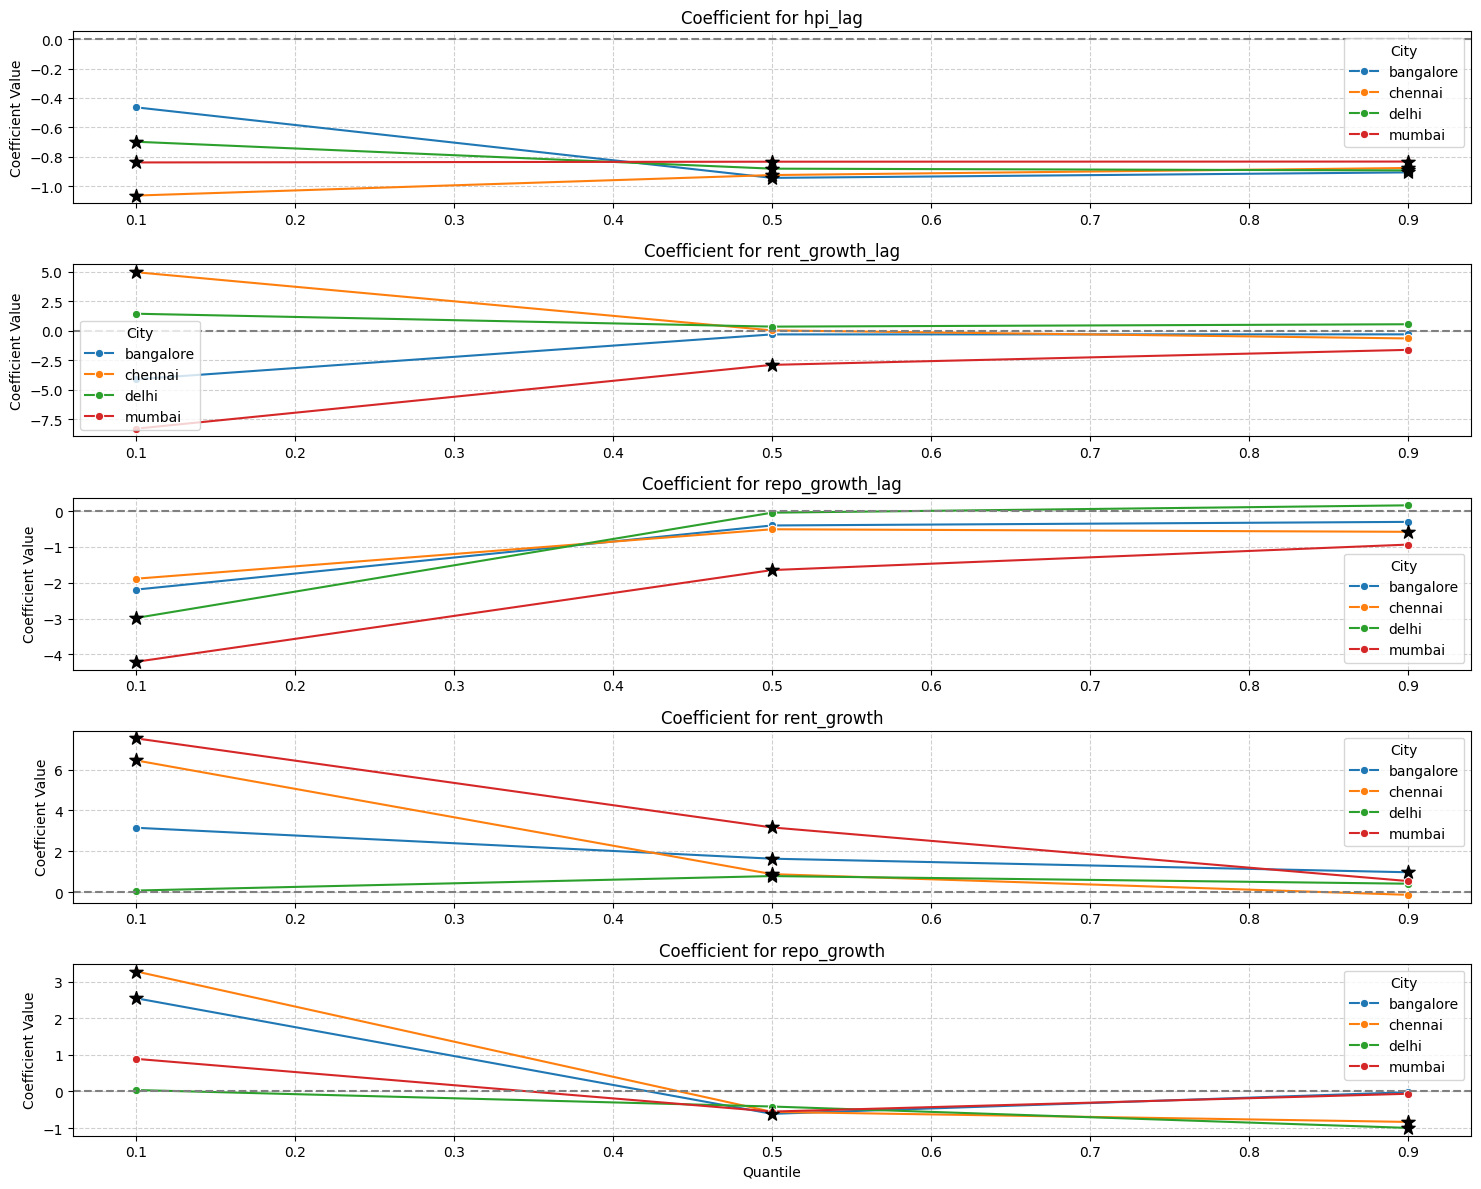

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Define the formula and quantiles (using the formula_city defined previously)
formula_city = "hpi_growth ~ hpi_lag + rent_growth_lag + repo_growth_lag + rent_growth + repo_growth" # Updated formula
quantiles = [0.1, 0.5, 0.9]
unique_cities = df_dyn['city'].unique()

# Store results
all_results_new = []

for city_name in unique_cities:
    df_city = df_dyn[df_dyn['city'] == city_name]

    if len(df_city) < 7:
        print(f"Skipping {city_name} due to insufficient observations.")
        continue

    for q in quantiles:
        model = smf.quantreg(formula_city, df_city)
        res = model.fit(q=q)

        # Extract coefficients and p-values
        params = res.params
        pvalues = res.pvalues

        for param_name in params.index:
            all_results_new.append({
                'City': city_name,
                'Quantile': q,
                'Variable': param_name,
                'Coefficient': params[param_name],
                'P-value': pvalues[param_name],
                'Significant (p<0.05)': pvalues[param_name] < 0.05
            })

# Create a DataFrame from the collected results
results_df_new = pd.DataFrame(all_results_new)

# --- Display as a Table ---
print("### Quantile Regression Coefficients and Significance by City and Quantile (Updated Formula)\n")
display(results_df_new)

# --- Plot the Coefficients ---
print("\n### Visualization of Coefficients Across Quantiles by City (Updated Formula)\n")

# Filter out the 'Intercept' for plotting clarity, as its scale can be very different
plot_df_new = results_df_new[results_df_new['Variable'].isin(['rent_growth', 'repo_growth', 'rent_growth_lag', 'hpi_lag', 'repo_growth_lag'])]

# Get unique variables to plot separately
unique_variables_new = plot_df_new['Variable'].unique()

plt.figure(figsize=(15, 12))
for i, var in enumerate(unique_variables_new):
    plt.subplot(len(unique_variables_new), 1, i + 1)
    sns.lineplot(data=plot_df_new[plot_df_new['Variable'] == var], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

    # Add significance markers
    for _, row in plot_df_new[(plot_df_new['Variable'] == var) & (plot_df_new['Significant (p<0.05)'] == True)].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficient for {var}')
    plt.axhline(0, color='grey', linestyle='--')
    plt.grid(True, linestyle='--', alpha=0.6)
    if i < len(unique_variables_new) - 1:
        plt.xlabel('') # Remove x-label for intermediate plots
    else:
        plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')

plt.tight_layout()
plt.show()


In [40]:
results_df_new.to_csv('quantile_regression_results.csv', index=False)


In [41]:
print(df.columns)

Index(['city', 'quarter', 'rent', 'hpi', 'hpi_growth', 'hpi_norm', 'repo_rate',
       'date', 'rent_growth', 'repo_growth', 'hpi_lag', 'rent_growth_lag',
       'repo_growth_lag'],
      dtype='object')


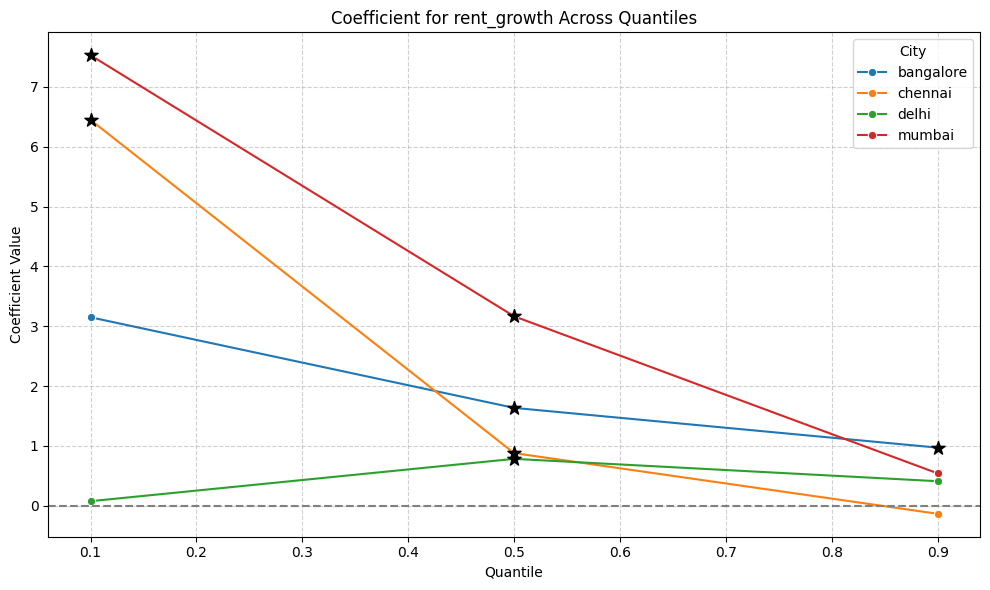

In [42]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df_new[plot_df_new['Variable'] == 'rent_growth'], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

# Add significance markers
for _, row in plot_df_new[(plot_df_new['Variable'] == 'rent_growth') & (plot_df_new['Significant (p<0.05)'] == True)].iterrows():
    plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

plt.title('Coefficient for rent_growth Across Quantiles')
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('Quantile')
plt.ylabel('Coefficient Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Coefficients for Each Variable Across Quantiles (Segmented by City)

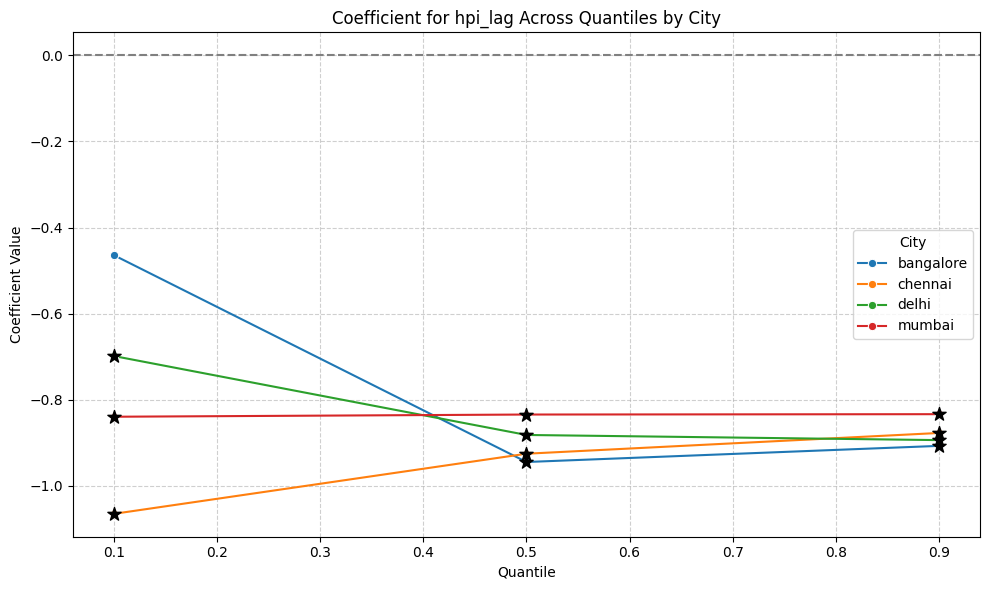

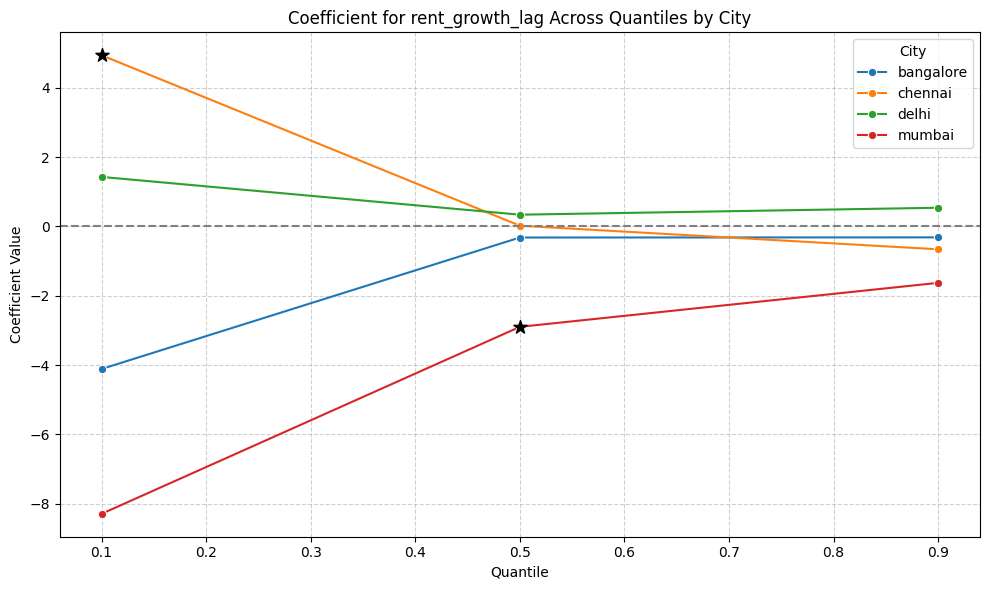

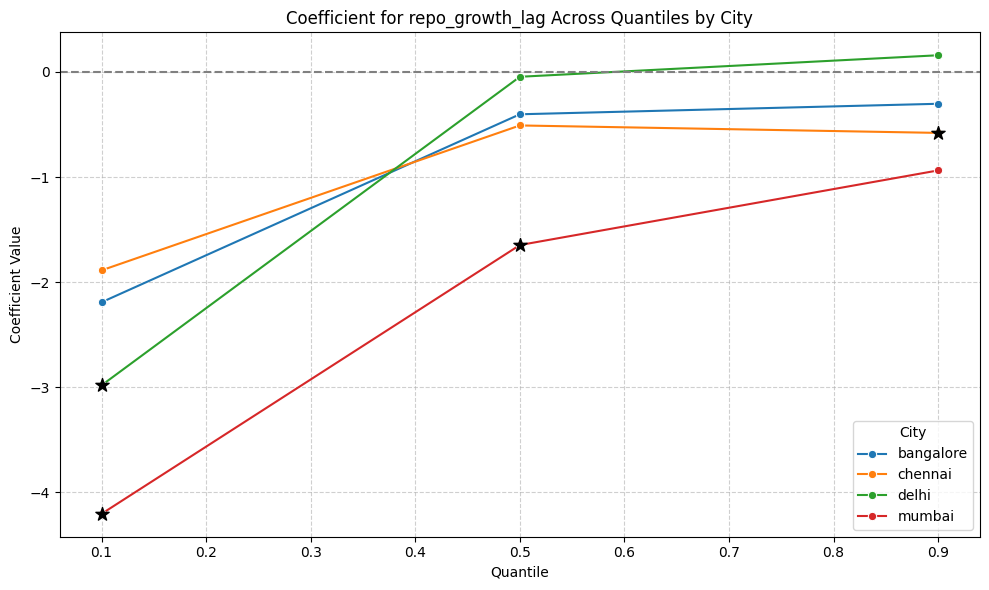

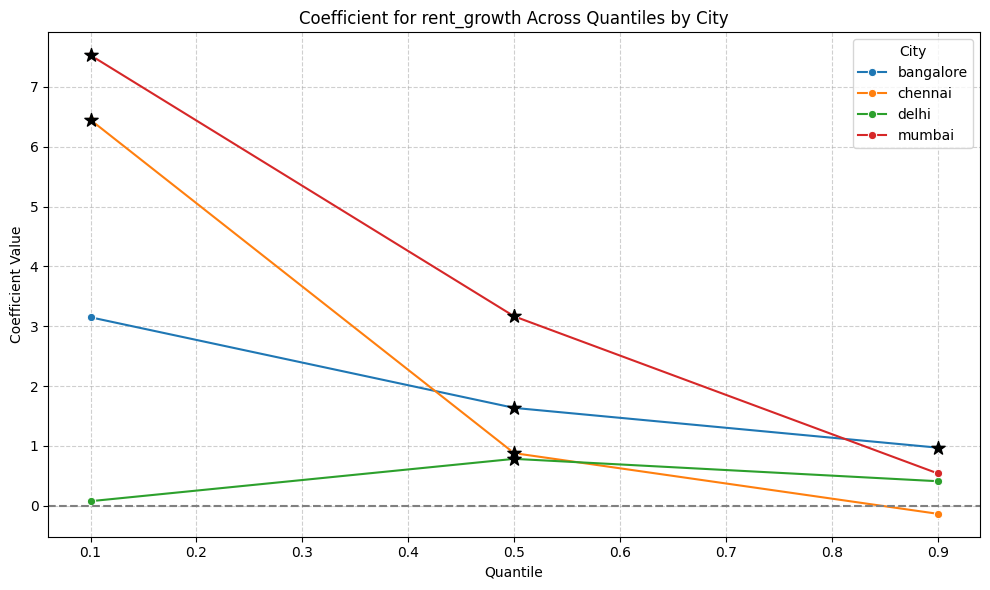

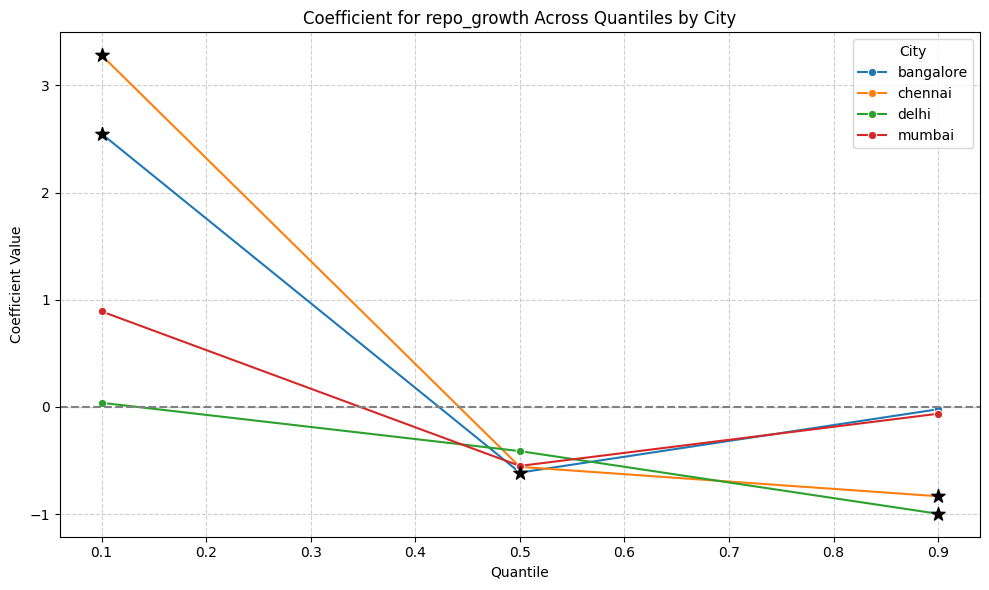

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save plots if it doesn't exist
plot_dir_vars = 'variable_plots_by_city'
os.makedirs(plot_dir_vars, exist_ok=True)

# Filter out the 'Intercept' for plotting clarity
plot_df_vars = results_df_new[results_df_new['Variable'].isin(['hpi_lag', 'rent_growth_lag', 'repo_growth_lag', 'rent_growth', 'repo_growth'])]
unique_variables_to_plot = plot_df_vars['Variable'].unique()

for var in unique_variables_to_plot:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=plot_df_vars[plot_df_vars['Variable'] == var], x='Quantile', y='Coefficient', hue='City', marker='o', errorbar=None)

    # Add significance markers
    for _, row in plot_df_vars[(plot_df_vars['Variable'] == var) & (plot_df_vars['Significant (p<0.05)'] == True)].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficient for {var} Across Quantiles by City')
    plt.axhline(0, color='grey', linestyle='--')
    plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    # Save the figure with a unique name
    plt.savefig(os.path.join(plot_dir_vars, f'{var}_coefficients_by_city.png'))
    plt.show()

### Coefficients for Each City Across Quantiles (Segmented by Variable)

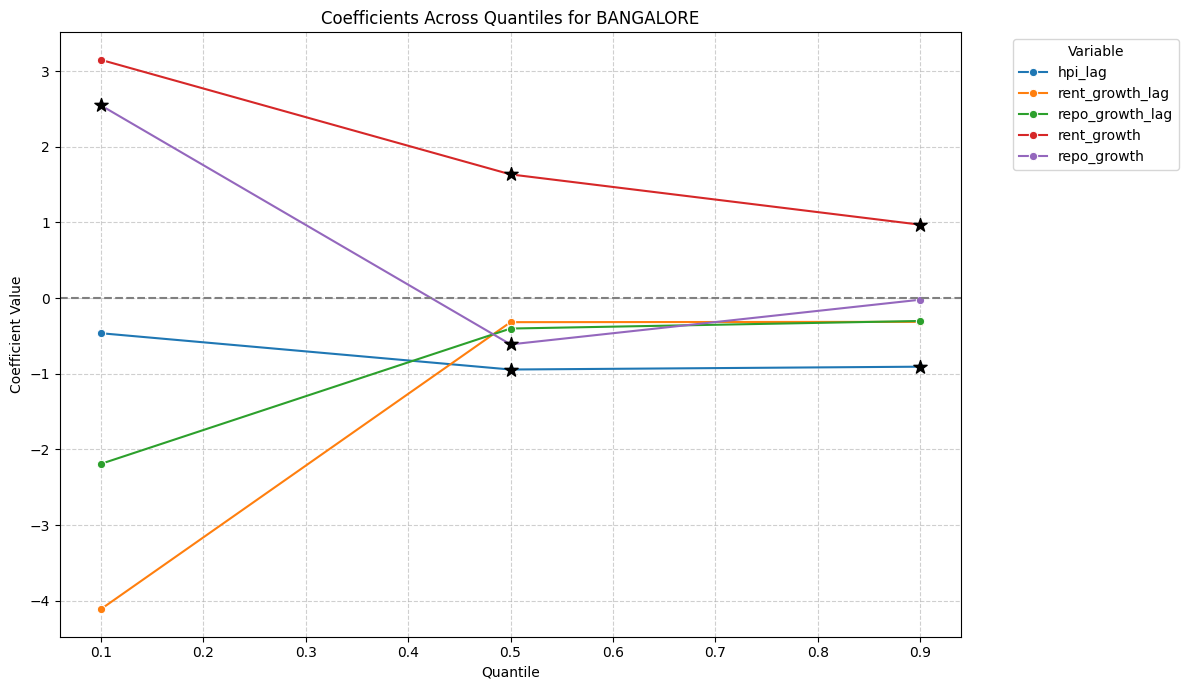

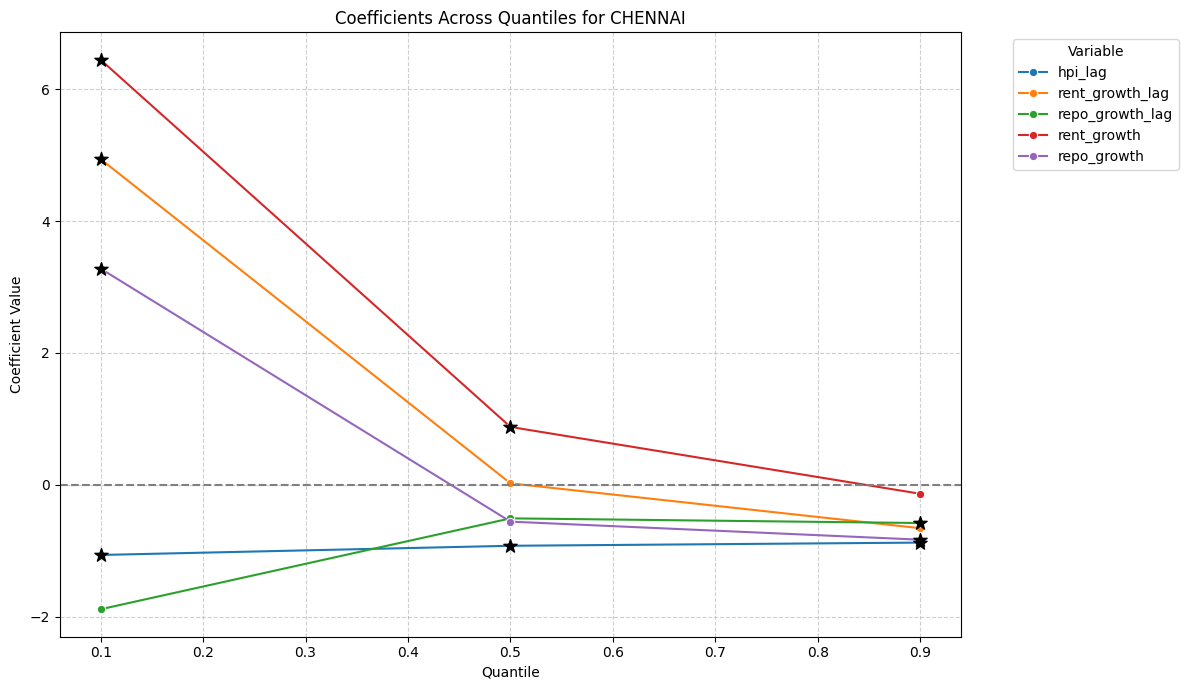

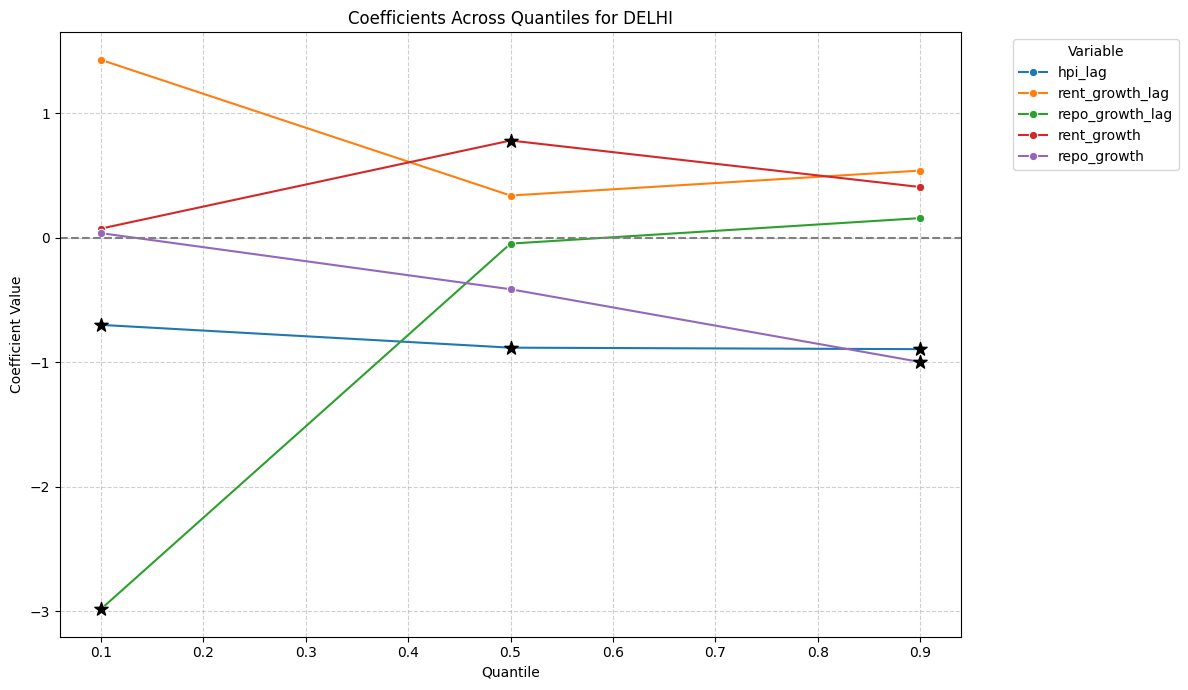

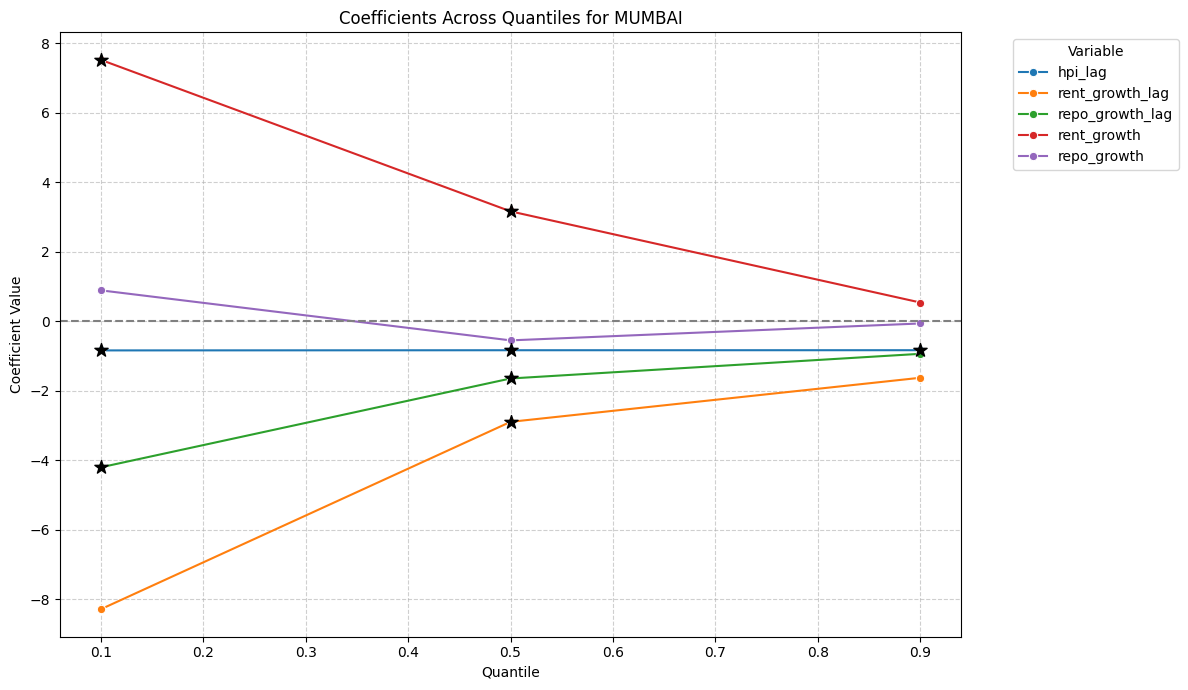

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save plots if it doesn't exist
plot_dir_cities = 'city_plots_by_variable'
os.makedirs(plot_dir_cities, exist_ok=True)

unique_cities_to_plot = results_df_new['City'].unique()

for city_name in unique_cities_to_plot:
    plt.figure(figsize=(12, 7))
    # Filter out Intercept for city-specific plots as well for better scaling of other coefficients
    df_city_plot = results_df_new[(results_df_new['City'] == city_name) & (~results_df_new['Variable'].str.contains('Intercept'))]

    sns.lineplot(data=df_city_plot, x='Quantile', y='Coefficient', hue='Variable', marker='o', errorbar=None)

    # Add significance markers
    for _, row in df_city_plot[df_city_plot['Significant (p<0.05)'] == True].iterrows():
        plt.scatter(row['Quantile'], row['Coefficient'], color='black', marker='*', s=100, zorder=5) # Star for significant

    plt.title(f'Coefficients Across Quantiles for {city_name.upper()}')
    plt.axhline(0, color='grey', linestyle='--')
    plt.xlabel('Quantile')
    plt.ylabel('Coefficient Value')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Variable', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # Save the figure with a unique name
    plt.savefig(os.path.join(plot_dir_cities, f'{city_name.lower()}_coefficients_by_variable.png'))
    plt.show()

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Create a directory to save plots if it doesn't exist
plot_dir = 'time_series_plots_by_city'
os.makedirs(plot_dir, exist_ok=True)

# Define the variables to plot, including lag variables
variables_to_plot = ['rent', 'hpi', 'repo_rate', 'hpi_lag', 'rent_growth_lag', 'repo_growth_lag']

unique_cities = df['city'].unique()

for city_name in unique_cities:
    df_city = df[df['city'] == city_name]

    for var in variables_to_plot:
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=df_city, x='date', y=var)
        plt.title(f'{var.replace("_", " ").title()} Time Series for {city_name.upper()}')
        plt.xlabel('Date')
        plt.ylabel(var.replace("_", " ").title())
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        # Save the figure
        plt.savefig(os.path.join(plot_dir, f'{city_name.lower()}_{var}_time_series.png'))
        plt.close() # Close the plot to free up memory

print(f"Time series plots saved in the '{plot_dir}' folder.")

Time series plots saved in the 'time_series_plots_by_city' folder.


In [46]:
rollingdf=df.groupby("city", observed=False)["rent_growth_lag"].rolling(8).std()

In [47]:
rollingdf.head()

city         
bangalore  4    NaN
           8    NaN
           12   NaN
           16   NaN
           20   NaN
Name: rent_growth_lag, dtype: float64

In [48]:
import pandas as pd

# Re-create df with necessary transformations
df = pd.read_csv('/content/merged_hpi_rent_repo.csv') # Corrected filename here
df = df.sort_values(["city","quarter"])
df["rent_growth"] = df.groupby("city")["rent"].pct_change(fill_method=None)
df["repo_growth"] = df.groupby("city")["repo_rate"].pct_change(fill_method=None)
# Assuming 'hpi_growth' exists or is calculated earlier. For this context, we can assume it's created during read_csv or earlier processing.
# If 'hpi_growth' is not present in the original CSV or calculated by user, this line will cause an error.
# Based on the notebook state, 'hpi_growth' column is present in the original df from `R7AEPz-c-Jn-`.
df = df.dropna(subset=["rent_growth","hpi_growth","repo_growth"])
df["city"]=df["city"].astype("category")
df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)
df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
df["repo_growth_lag"] = df.groupby("city")["repo_growth"].shift(1)

bangalore_rent_growth_lag = df[df['city'] == 'bangalore']['rent_growth_lag']
display(bangalore_rent_growth_lag.head(20))

/tmp/ipykernel_4531/927159723.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["hpi_lag"] = df.groupby("city")["hpi_growth"].shift(1)
/tmp/ipykernel_4531/927159723.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["rent_growth_lag"] = df.groupby("city")["rent_growth"].shift(1)
/tmp/ipykernel_4531/927159723.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["repo_growth_lag"] = df.groupby("city")["repo_g

,rent_growth_lag
4,NaN
8,0.044500
12,0.097176
16,0.064463
20,0.190491
24,-0.003357
28,0.070559
32,0.041062
36,0.016893
37,0.082222


In [49]:
df["rent_var_rolling"] = (
    df[df["city"]=="bangalore"]
    .sort_values("quarter")
    ["rent_growth_lag"]
    .rolling(window=4)
    .var()
)

In [50]:
df["rent_var_rolling_all_cities"] = df.groupby("city", observed=False)["rent_growth_lag"].transform(lambda x: x.rolling(window=4).var())
display(df.head())

,city,quarter,rent,hpi,hpi_growth,hpi_norm,repo_rate,date,rent_growth,repo_growth,hpi_lag,rent_growth_lag,repo_growth_lag,rent_var_rolling,rent_var_rolling_all_cities
4,bangalore,Q1 2015,104.4500,180.400000,0.237475,1.741313,7.782887,2015-01-01,0.044500,-0.116068,NaN,NaN,NaN,NaN,NaN
8,bangalore,Q1 2016,114.6000,208.418714,0.144372,2.011764,7.657853,2016-01-01,0.097176,-0.016065,0.237475,0.044500,-0.116068,NaN,NaN
12,bangalore,Q1 2017,121.9875,220.607905,0.056838,2.129420,6.962920,2017-01-01,0.064463,-0.090748,0.144372,0.097176,-0.016065,NaN,NaN
16,bangalore,Q1 2018,145.2250,227.657667,0.031456,2.197468,7.466353,2018-01-01,0.190491,0.072302,0.056838,0.064463,-0.090748,NaN,NaN
20,bangalore,Q1 2019,144.7375,244.842538,0.072772,2.363345,7.397403,2019-01-01,-0.003357,-0.009235,0.031456,0.190491,0.072302,0.004179,0.004179


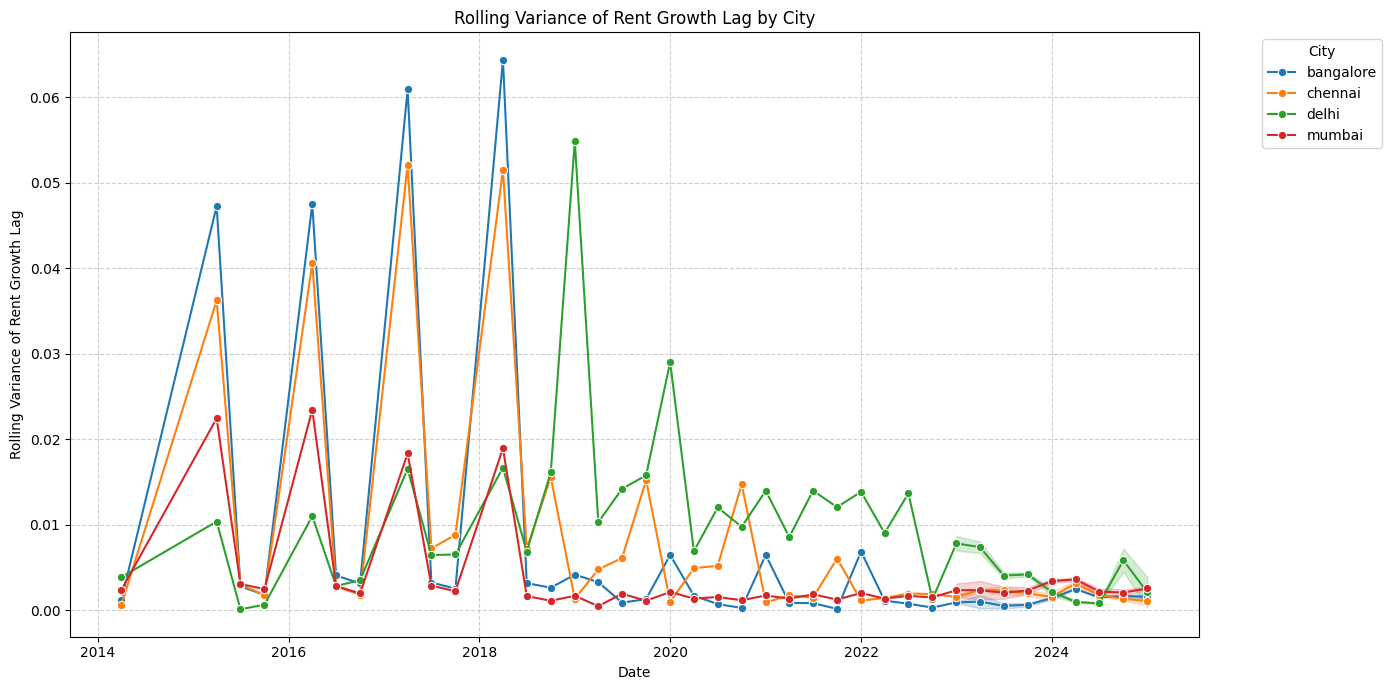

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date' column is in datetime format for plotting
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14, 7))
sns.lineplot(data=df.dropna(subset=['rent_var_rolling_all_cities']), x='date', y='rent_var_rolling_all_cities', hue='city', marker='o')
plt.title('Rolling Variance of Rent Growth Lag by City')
plt.xlabel('Date')
plt.ylabel('Rolling Variance of Rent Growth Lag')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [52]:
# Calculate rolling variance for other relevant variables
df["hpi_growth_var_rolling"] = df.groupby("city", observed=False)["hpi_growth"].transform(lambda x: x.rolling(window=4).var())
df["repo_growth_var_rolling"] = df.groupby("city", observed=False)["repo_growth"].transform(lambda x: x.rolling(window=4).var())
df["hpi_lag_var_rolling"] = df.groupby("city", observed=False)["hpi_lag"].transform(lambda x: x.rolling(window=4).var())
df["rent_growth_lag_var_rolling"] = df.groupby("city", observed=False)["rent_growth_lag"].transform(lambda x: x.rolling(window=4).var())
df["repo_growth_lag_var_rolling"] = df.groupby("city", observed=False)["repo_growth_lag"].transform(lambda x: x.rolling(window=4).var())

display(df.head())

,city,quarter,rent,hpi,hpi_growth,hpi_norm,repo_rate,date,rent_growth,repo_growth,hpi_lag,rent_growth_lag,repo_growth_lag,rent_var_rolling,rent_var_rolling_all_cities,hpi_growth_var_rolling,repo_growth_var_rolling,hpi_lag_var_rolling,rent_growth_lag_var_rolling,repo_growth_lag_var_rolling
4,bangalore,Q1 2015,104.4500,180.400000,0.237475,1.741313,7.782887,2015-01-01,0.044500,-0.116068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,bangalore,Q1 2016,114.6000,208.418714,0.144372,2.011764,7.657853,2016-01-01,0.097176,-0.016065,0.237475,0.044500,-0.116068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,bangalore,Q1 2017,121.9875,220.607905,0.056838,2.129420,6.962920,2017-01-01,0.064463,-0.090748,0.144372,0.097176,-0.016065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,bangalore,Q1 2018,145.2250,227.657667,0.031456,2.197468,7.466353,2018-01-01,0.190491,0.072302,0.056838,0.064463,-0.090748,NaN,NaN,0.008733,0.007175,NaN,NaN,NaN
20,bangalore,Q1 2019,144.7375,244.842538,0.072772,2.363345,7.397403,2019-01-01,-0.003357,-0.009235,0.031456,0.190491,0.072302,0.004179,0.004179,0.002345,0.004443,0.008733,0.004179,0.007175


### Visualizing Rolling Variance for Other Variables

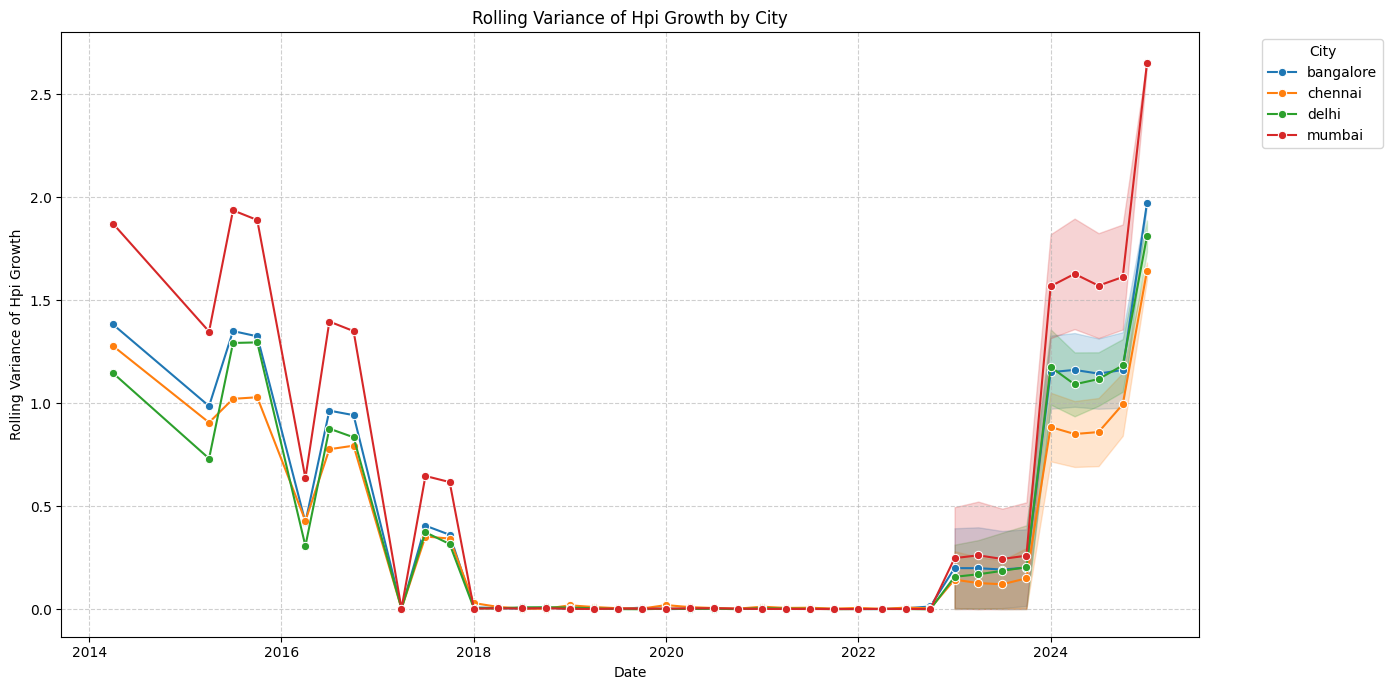

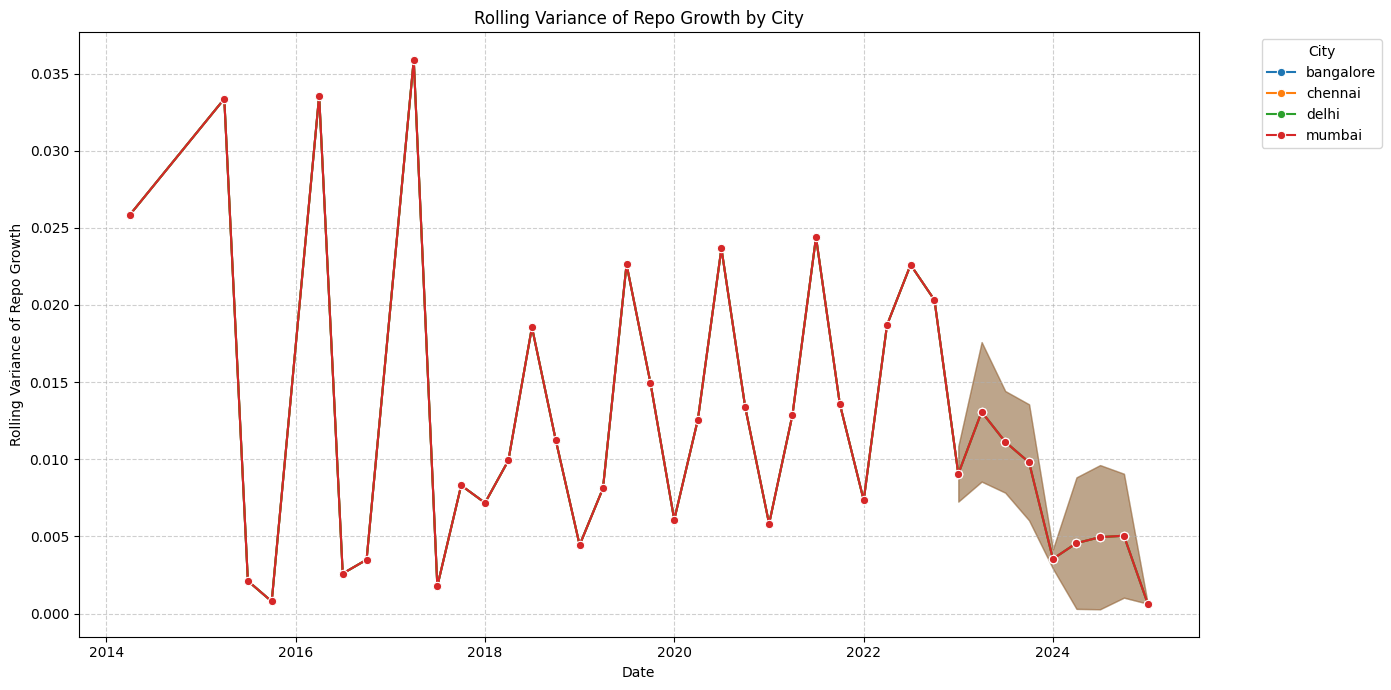

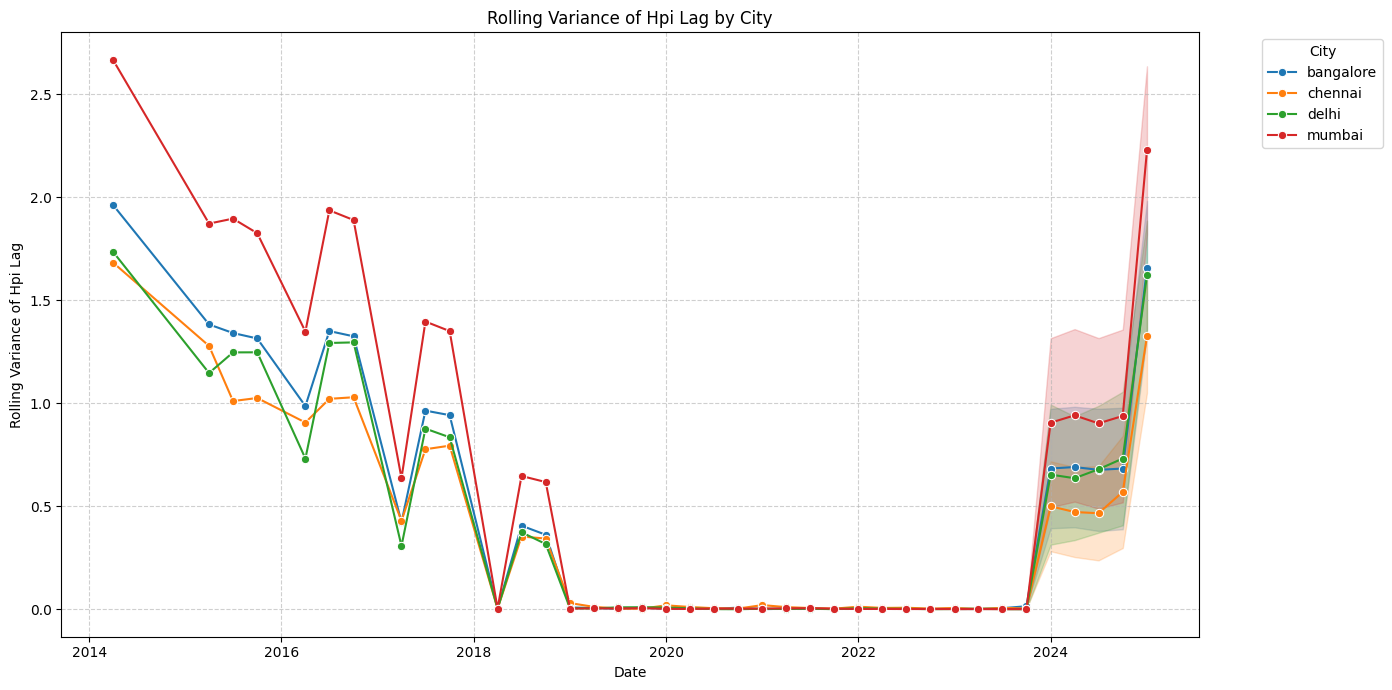

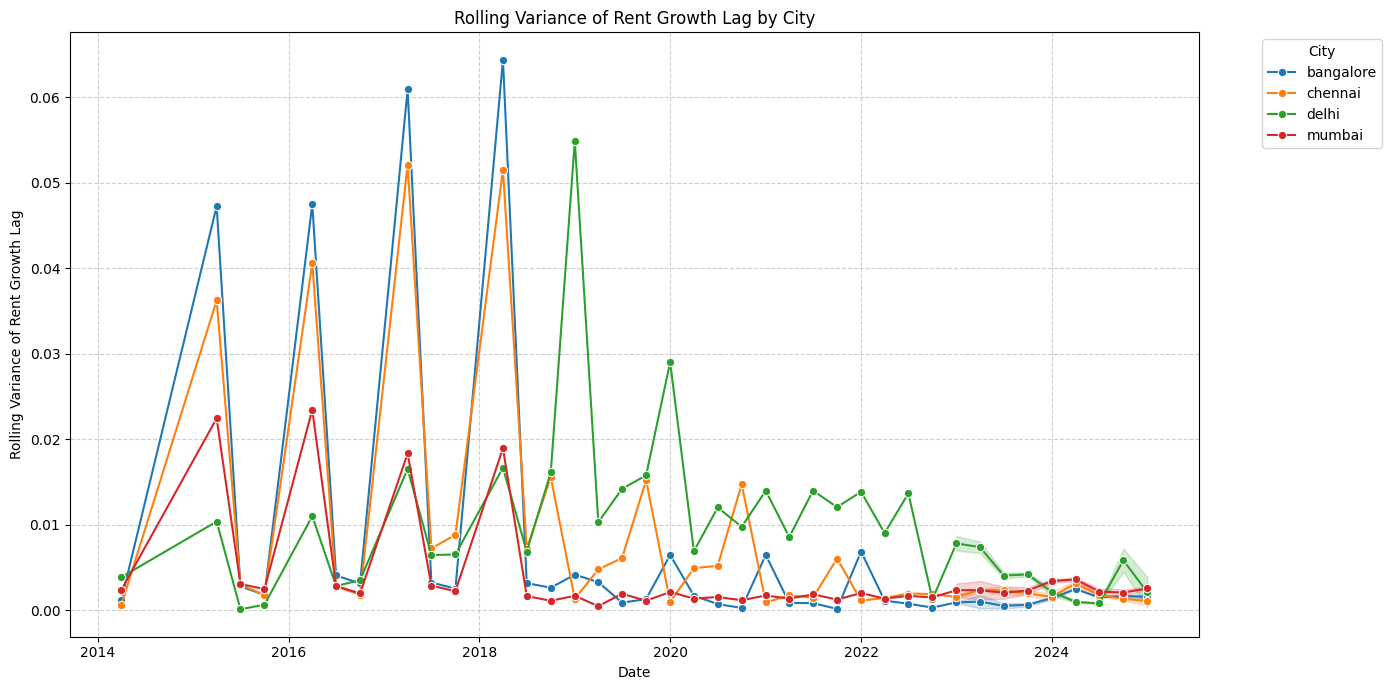

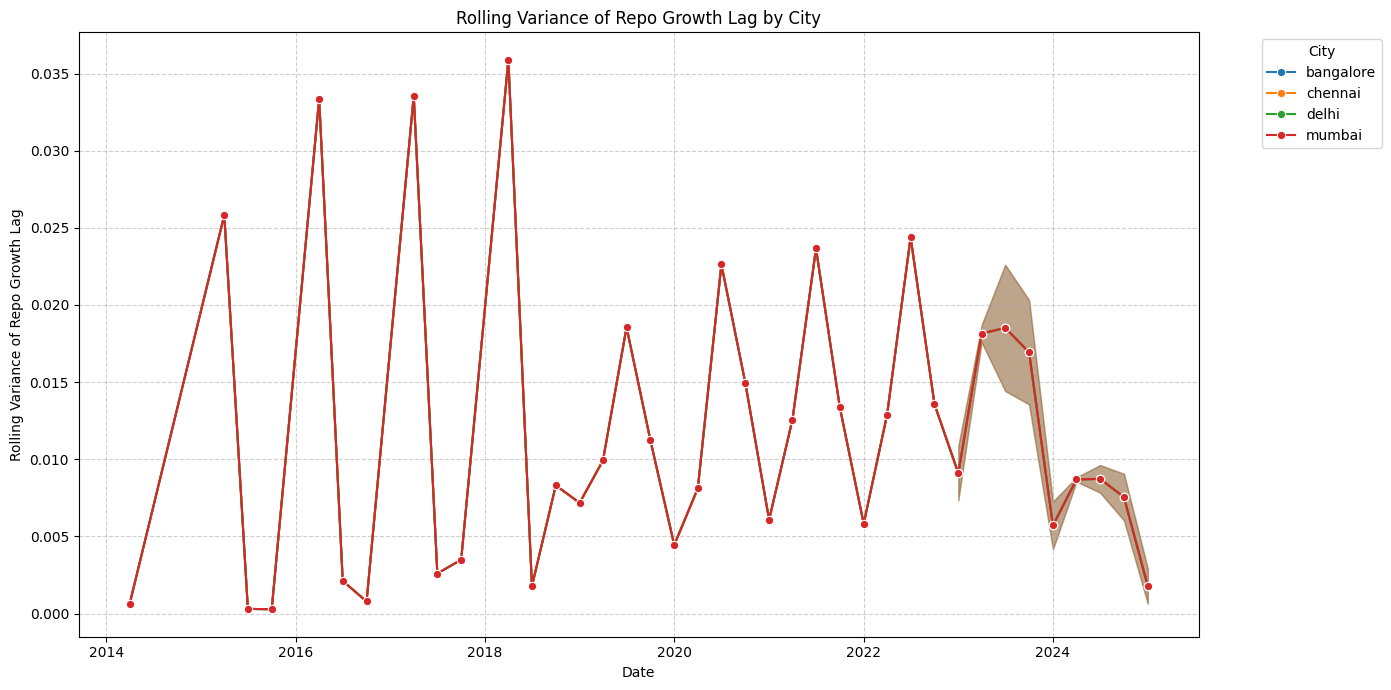

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure 'date' column is in datetime format for plotting
df['date'] = pd.to_datetime(df['date'])

rolling_variance_cols = [
    'hpi_growth_var_rolling',
    'repo_growth_var_rolling',
    'hpi_lag_var_rolling',
    'rent_growth_lag_var_rolling',
    'repo_growth_lag_var_rolling'
]

# Create a directory to save plots if it doesn't exist
plot_dir_rolling_var = 'rolling_variance_plots'
os.makedirs(plot_dir_rolling_var, exist_ok=True)

for col in rolling_variance_cols:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df.dropna(subset=[col]), x='date', y=col, hue='city', marker='o')
    plt.title(f'Rolling Variance of {col.replace("_var_rolling", "").replace("_", " ").title()} by City')
    plt.xlabel('Date')
    plt.ylabel(f'Rolling Variance of {col.replace("_var_rolling", "").replace("_", " ").title()}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # Save the figure to the specified directory
    plt.savefig(os.path.join(plot_dir_rolling_var, f'{col}.png'))
    plt.show()